In [8]:
import pandas as pd
import seaborn as sns

Aca importamos un dataset que armamos anteriormente en otro otebook. Vamos a hacer una prediccion de la estacion de destino de la bicicleta para la estación de origen constitución.

Acá hicimos anteriormente transformaciones sobre la fecha, obteniendo diferentes columnas de dia, mes año. Además, obtuvimos un dataset de temperatura, precipitaciones y viento, para generar un posible indice que nos mejore la predicción.

In [6]:
df = pd.read_parquet("dataset_general.parquet")
df = df[ df["estacion_origen"] == '236 - UBA SOCIALES']
df = df.drop(columns="grupo_edad")

para hacer el analisis vamos a hacerlo sobre la estación de la uba de sociales

In [7]:
df

,year_key,month_of_year,day_of_month,iso_day_of_week,estacion_origen,estacion_destino,tavg,prcp,wspd
622,2024,10,18,5,236 - UBA SOCIALES,131- HOSPITAL DE CLÍNICAS,21.1,0.0,8.9
1721,2024,10,18,5,236 - UBA SOCIALES,064 - RIOBAMBA,21.1,0.0,8.9
1736,2024,10,18,5,236 - UBA SOCIALES,286 - FILOSOFIA Y LETRAS,21.1,0.0,8.9
1948,2024,10,18,5,236 - UBA SOCIALES,041 - PARQUE PATRICIOS II,21.1,0.0,8.9
2450,2024,10,18,5,236 - UBA SOCIALES,236 - UBA SOCIALES,21.1,0.0,8.9
...,...,...,...,...,...,...,...,...,...
3495632,2024,10,25,5,236 - UBA SOCIALES,073 - Ruy Díaz de Guzmán,22.6,3.3,6.7
3500105,2024,10,28,1,236 - UBA SOCIALES,152 - JULIETA LANTERI,24.4,0.0,8.2
3500462,2024,10,26,6,236 - UBA SOCIALES,179 - CASA SAN,16.9,0.0,4.7
3500495,2024,10,26,6,236 - UBA SOCIALES,008 - Congreso,16.9,0.0,4.7


Para analizar desbalanceo de la variable de salida, vamos a ver la cantidad de salida de las 30 estaciones de destino mas grandes

In [24]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]

<Axes: xlabel='count', ylabel='estacion_destino'>

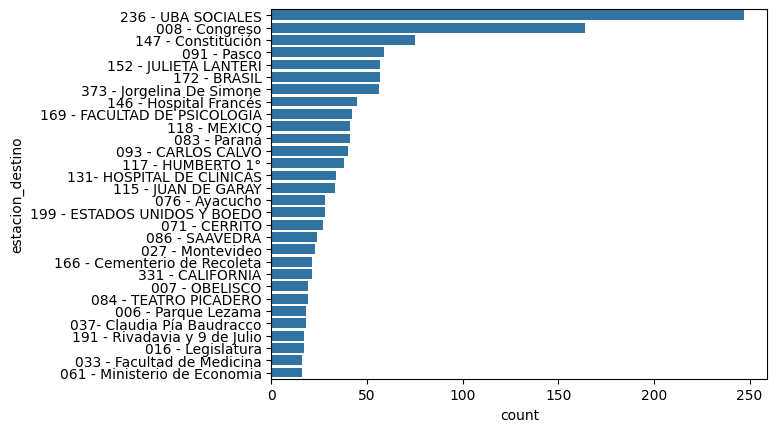

In [25]:
sns.countplot(df_top30, y="estacion_destino", order=top_30)

Podemos ver como en general las clases presentan una distribucion medianamente uniforme descendente, salvo por dos casos atipicos: la misma estación de uba sociales, y la estación de congreso. Vamos a ver metodologías para corregir estos desbalanceos

<Axes: xlabel='estacion_destino', ylabel='Count'>

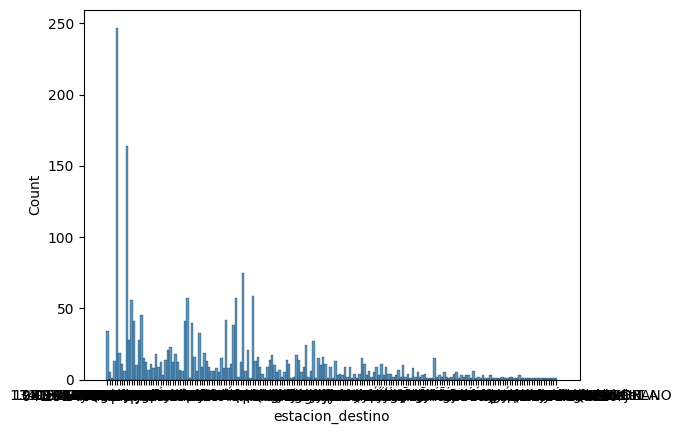

In [9]:
sns.histplot(df, x="estacion_destino")